# DEIMv2 实时安全帽分析

本 Notebook 使用 DEIMv2 模型对视频进行实时安全帽/马甲检测和分析。

支持：
- 本地视频文件（如 test.mp4）
- 网络视频流地址（如 RTSP/HTTP 流）

功能：
- 实时安全帽和工作服检测
- 人员合规统计
- 可视化展示

## 1. 导入依赖

In [1]:
import torch
import torch.nn as nn
import cv2
import numpy as np
from PIL import Image, ImageDraw, ImageFont
import torchvision.transforms as T
from collections import deque
import time
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import sys
import os

# 配置 matplotlib 支持中文
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch 版本: {torch.__version__}')
print(f'使用设备: {device}')
print("✅ 依赖导入成功")

PyTorch 版本: 2.5.1+cpu
使用设备: cpu
✅ 依赖导入成功


## 2. 配置与加载模型

In [2]:
# 路径配置
import pathlib
DEIMV2_ROOT = pathlib.Path().resolve().parent
if str(DEIMV2_ROOT) not in sys.path:
    sys.path.insert(0, str(DEIMV2_ROOT))

from engine.core import YAMLConfig

CONFIG_PATH = DEIMV2_ROOT / "configs" / "deimv2" / "deimv2_hgnetv2_b1_helmet_finetune.yml"
MODEL_PATH = DEIMV2_ROOT / "outputs" / "deimv2_hgnetv2_b1_helmet_finetune" / "best_stg1.pth"

print(f"配置文件: {CONFIG_PATH}")
print(f"模型权重: {MODEL_PATH}")

def load_model(config_path, model_path, device):
    cfg = YAMLConfig(str(config_path))
    if "HGNetv2" in cfg.yaml_cfg:
        cfg.yaml_cfg["HGNetv2"]["pretrained"] = False
    
    checkpoint = torch.load(str(model_path), map_location="cpu", weights_only=False)
    if "ema" in checkpoint:
        state = checkpoint["ema"]["module"]
    elif "model" in checkpoint:
        state = checkpoint["model"]
    else:
        state = checkpoint
        
    state = {k.replace("module.", "", 1): v for k, v in state.items()}
    cfg.model.load_state_dict(state, strict=False)
    
    class DeployModel(nn.Module):
        def __init__(self):
            super().__init__()
            self.model = cfg.model.deploy()
            self.postprocessor = cfg.postprocessor.deploy()
            
        def forward(self, images, orig_sizes):
            out = self.model(images)
            return self.postprocessor(out, orig_sizes)
            
    model = DeployModel().to(device)
    model.eval()
    eval_size = cfg.yaml_cfg.get("eval_spatial_size", [640, 640])
    vit_backbone = bool(cfg.yaml_cfg.get("DINOv3STAs", False))
    return model, eval_size, vit_backbone

print("正在加载 DEIMv2 模型...")
model, EVAL_SIZE, VIT_BACKBONE = load_model(CONFIG_PATH, MODEL_PATH, device)
print("✅ 模型加载成功！")
print(f"输入尺寸: {EVAL_SIZE}")

配置文件: D:\AI\Git\DEIMv2\configs\deimv2\deimv2_hgnetv2_b1_helmet_finetune.yml
模型权重: D:\AI\Git\DEIMv2\outputs\deimv2_hgnetv2_b1_helmet_finetune\best_stg1.pth
正在加载 DEIMv2 模型...
        ### Backbone.act: relu ###     
        ### Backbone.act: relu ###     
     --- Use Gateway@False ---
     --- Use Share Bbox Head@True ---
     --- Use Share Score Head@False ---
     --- Wide Layer@1 ---
✅ 模型加载成功！
输入尺寸: [640, 640]


## 3. 设置类别与检测配置

In [8]:
# COCO 类别映射 (根据 dataset/helmet_detection2_highprec_finetune.yml)
CLASS_CONFIG = {
    0: {"name": "佩戴安全帽",   "color": "#00CC44", "threshold": 0.40},
    1: {"name": "未佩戴安全帽", "color": "#FF3333", "threshold": 0.40},
    2: {"name": "未穿反光衣",   "color": "#FF8C00", "threshold": 0.40},
    3: {"name": "穿反光衣",     "color": "#3399FF", "threshold": 0.40},
}

print("✅ 类别与检测配置已完成")
for k, v in CLASS_CONFIG.items():
    print(f"  ID={k}: {v['name']} (置信度 > {v['threshold']})")

✅ 类别与检测配置已完成
  ID=0: 佩戴安全帽 (置信度 > 0.4)
  ID=1: 未佩戴安全帽 (置信度 > 0.4)
  ID=2: 未穿反光衣 (置信度 > 0.4)
  ID=3: 穿反光衣 (置信度 > 0.4)


## 4. 定义安全帽检测与分析类

In [9]:
class HelmetAnalyzer:
    def __init__(self, model, device, eval_size, vit_backbone):
        self.model = model
        self.device = device
        self.eval_size = eval_size
        self.vit_backbone = vit_backbone
        
        self.transform = T.Compose([
            T.Resize(self.eval_size),
            T.ToTensor(),
            *([T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])] if self.vit_backbone else [])
        ])
        
        self.fps_history = deque(maxlen=30)
        
    def detect_frame(self, image):
        if isinstance(image, np.ndarray):
            image = Image.fromarray(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        
        w, h = image.size
        orig_size = torch.tensor([[w, h]], dtype=torch.float32).to(self.device)
        input_tensor = self.transform(image).unsqueeze(0).to(self.device)
        
        with torch.no_grad():
            labels, boxes, scores = self.model(input_tensor, orig_size)
            
        labels = labels[0].cpu()
        boxes = boxes[0].cpu()
        scores = scores[0].cpu()
        
        detections = []
        for label, bbox, score in zip(labels, boxes, scores):
            label_id = int(label.item())
            score_val = float(score.item())
            if label_id in CLASS_CONFIG and score_val >= CLASS_CONFIG[label_id]["threshold"]:
                detection = {
                    "class_id": label_id,
                    "label": CLASS_CONFIG[label_id]["name"],
                    "bbox": [b.item() for b in bbox],  # x1, y1, x2, y2
                    "confidence": score_val,
                    "color": CLASS_CONFIG[label_id]["color"]
                }
                detections.append(detection)
                
        return detections

    def draw_detections(self, image, detections):
        if isinstance(image, np.ndarray):
            image = Image.fromarray(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        else:
            image = image.copy()
            
        draw = ImageDraw.Draw(image)
        # 尝试加载中文字体，如果不存在则使用默认
        try:
            font = ImageFont.truetype("simhei.ttf", 20)
        except:
            font = ImageFont.load_default()
            
        for det in detections:
            x1, y1, x2, y2 = det["bbox"]
            color = det["color"]
            label = det["label"]
            conf = det["confidence"]
            
            draw.rectangle([x1, y1, x2, y2], outline=color, width=3)
            label_text = f"{label}: {conf:.2f}"
            
            try:
                tw = draw.textlength(label_text, font=font)
                th = 20
            except:
                tw, th = 80, 16
                
            draw.rectangle([x1, max(0, y1 - th - 4), x1 + tw + 4, max(th, y1)], fill=color)
            draw.text((x1 + 2, max(0, y1 - th - 2)), label_text, fill="white", font=font)
            
        return image
    
    def process_video(self, video_source, output_path=None, max_frames=None, display_live=True):
        cap = cv2.VideoCapture(video_source)
        if not cap.isOpened():
            print(f"❌ 无法打开视频源: {video_source}")
            return
            
        fps = cap.get(cv2.CAP_PROP_FPS)
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        
        print(f"\n📹 视频信息: {width}x{height} @ {fps:.2f} FPS | 总帧数: {total_frames}")
        
        out = None
        if output_path:
            fourcc = cv2.VideoWriter_fourcc(*'mp4v')
            out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
            print(f"输出路径: {output_path}")
            
        frame_count = 0
        print("\n🚀 开始处理视频...\n")
        
        try:
            while True:
                ret, frame = cap.read()
                if not ret:
                    break
                    
                frame_count += 1
                if max_frames and frame_count > max_frames:
                    break
                    
                start_time = time.time()
                detections = self.detect_frame(frame)
                inference_time = time.time() - start_time
                
                current_fps = 1.0 / inference_time if inference_time > 0 else 0
                self.fps_history.append(current_fps)
                avg_fps = np.mean(self.fps_history)
                
                result_frame_pil = self.draw_detections(frame, detections)
                result_frame = cv2.cvtColor(np.array(result_frame_pil), cv2.COLOR_RGB2BGR)
                
                # 添加覆盖信息
                overlay = result_frame.copy()
                cv2.rectangle(overlay, (10, 10), (250, 80), (0, 0, 0), -1)
                cv2.addWeighted(overlay, 0.6, result_frame, 0.4, 0, result_frame)
                cv2.putText(result_frame, f"Detections: {len(detections)}", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
                cv2.putText(result_frame, f"FPS: {avg_fps:.1f}", (20, 70), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 0), 2)
                
                if out:
                    out.write(result_frame)
                    
                if display_live and frame_count % 5 == 0:
                    clear_output(wait=True)
                    plt.figure(figsize=(10, 6))
                    plt.imshow(cv2.cvtColor(result_frame, cv2.COLOR_BGR2RGB))
                    plt.axis('off')
                    plt.title(f"Frame {frame_count} - Detections: {len(detections)} - FPS: {avg_fps:.1f}")
                    plt.tight_layout()
                    plt.show()
                    
                if frame_count % 30 == 0:
                    progress = f"Frame {frame_count}/{total_frames}" if total_frames > 0 else f"Frame {frame_count}"
                    print(f"\r⏳ {progress} | FPS: {avg_fps:.1f}", end="")
                    
        except KeyboardInterrupt:
            print("\n⚠️ 用户中断处理")
        finally:
            cap.release()
            if out:
                out.release()
            cv2.destroyAllWindows()
            
        print("\n\n✅ 视频处理完成！")

print("✅ HelmetAnalyzer 类定义完成")

✅ HelmetAnalyzer 类定义完成


## 5. 实例化分析器并运行

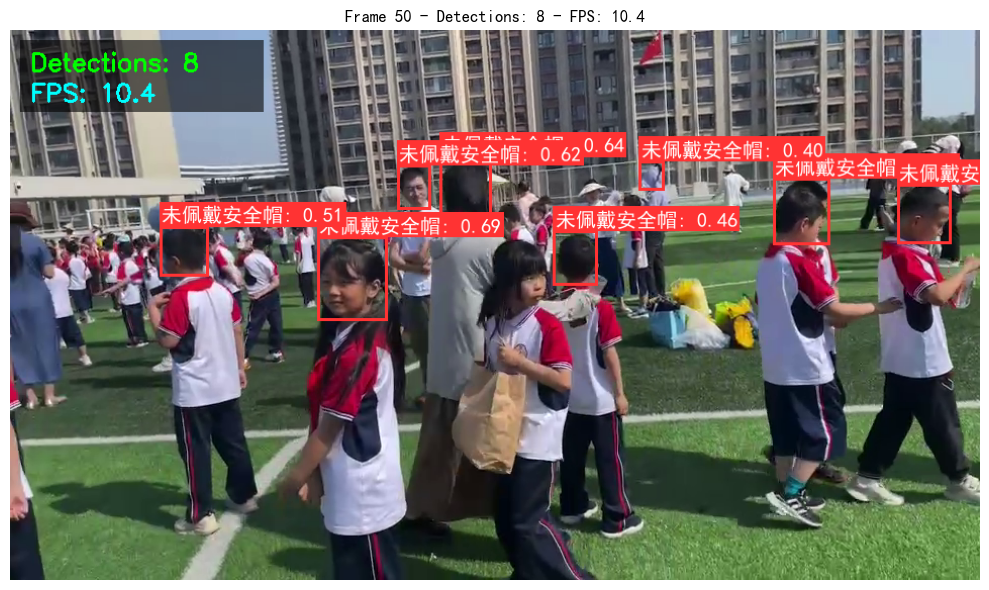



✅ 视频处理完成！


In [10]:
analyzer = HelmetAnalyzer(model, device, EVAL_SIZE, VIT_BACKBONE)

# 测试运行
video_path = "xx.mp4"  # 替换为你的视频路径
output_path = "test_helmet_output.mp4"

import os
if os.path.exists(video_path):
    analyzer.process_video(
        video_source=video_path,
        output_path=output_path,
        max_frames=50,
        display_live=True
    )
else:
    print(f"测试视频 {video_path} 不存在，可以通过上面单元格进行单帧图像测试。")

## 6. 单帧测试

In [11]:
test_image_path = "example.jpg"  # 替换为你的测试图片路径

if os.path.exists(test_image_path):
    image = Image.open(test_image_path).convert("RGB")
    print(f"图片尺寸: {image.size[0]}x{image.size[1]}")
    
    detections = analyzer.detect_frame(image)
    print(f"\n检测到 {len(detections)} 个目标:")
    for det in detections:
        print(f"  - {det['label']} (置信度: {det['confidence']:.2f})")
        
    result_image = analyzer.draw_detections(image, detections)
    display(result_image)
else:
    print(f"测试图片不存在: {test_image_path}")

测试图片不存在: example.jpg
